In [1]:
import geopandas as gpd
import libpysal as lps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import esda

In [2]:
gdf = gpd.read_file("data/berlin-neighbourhoods.geojson")

In [3]:
bl_df = pd.read_csv("data/berlin-listings.csv")
geometry = gpd.points_from_xy(x=bl_df.longitude, y=bl_df.latitude, crs="epsg:4326")
bl_gdf = gpd.GeoDataFrame(bl_df, geometry=geometry)

In [4]:
bl_gdf["price"] = bl_gdf["price"].astype("float32")
sj_gdf = gpd.sjoin(
    gdf, bl_gdf, how="inner", predicate="intersects", lsuffix="left", rsuffix="right"
)
median_price_gb = sj_gdf["price"].groupby([sj_gdf["neighbourhood_group"]]).mean()
median_price_gb

neighbourhood_group
Charlottenburg-Wilm.        58.556408
Friedrichshain-Kreuzberg    55.492809
Lichtenberg                 44.584270
Marzahn - Hellersdorf       54.246754
Mitte                       60.387890
Neukölln                    45.135948
Pankow                      60.282516
Reinickendorf               43.682465
Spandau                     48.236561
Steglitz - Zehlendorf       54.445683
Tempelhof - Schöneberg      53.704407
Treptow - Köpenick          51.222004
Name: price, dtype: float32

In [5]:
gdf = gdf.join(median_price_gb, on="neighbourhood_group")
gdf.rename(columns={"price": "median_pri"}, inplace=True)
gdf.head(15)

,neighbourhood,neighbourhood_group,geometry,median_pri
0,Blankenfelde/Niederschönhausen,Pankow,"MULTIPOLYGON (((13.41191 52.61487, 13.41183 52...",60.282516
1,Helmholtzplatz,Pankow,"MULTIPOLYGON (((13.41405 52.54929, 13.41422 52...",60.282516
2,Wiesbadener Straße,Charlottenburg-Wilm.,"MULTIPOLYGON (((13.30748 52.46788, 13.30743 52...",58.556408
3,Schmöckwitz/Karolinenhof/Rauchfangswerder,Treptow - Köpenick,"MULTIPOLYGON (((13.70973 52.3963, 13.70926 52....",51.222004
4,Müggelheim,Treptow - Köpenick,"MULTIPOLYGON (((13.73762 52.4085, 13.73773 52....",51.222004
5,Biesdorf,Marzahn - Hellersdorf,"MULTIPOLYGON (((13.56643 52.5351, 13.56697 52....",54.246754
6,Nord 1,Reinickendorf,"MULTIPOLYGON (((13.33669 52.62265, 13.33663 52...",43.682465
7,West 5,Reinickendorf,"MULTIPOLYGON (((13.28138 52.59958, 13.28158 52...",43.682465
8,Frankfurter Allee Nord,Friedrichshain-Kreuzberg,"MULTIPOLYGON (((13.4532 52.51682, 13.45321 52....",55.492809
9,Buch,Pankow,"MULTIPOLYGON (((13.4645 52.65055, 13.46457 52....",60.282516


In [6]:
pd.isnull(gdf["median_pri"]).sum()

np.int64(2)

In [7]:
gdf["median_pri"] = gdf["median_pri"].fillna(gdf["median_pri"].mean())

<Axes: >

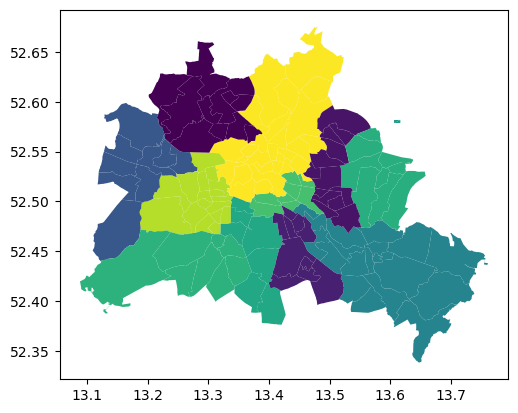

In [8]:
gdf.plot(column="median_pri")

<Axes: >

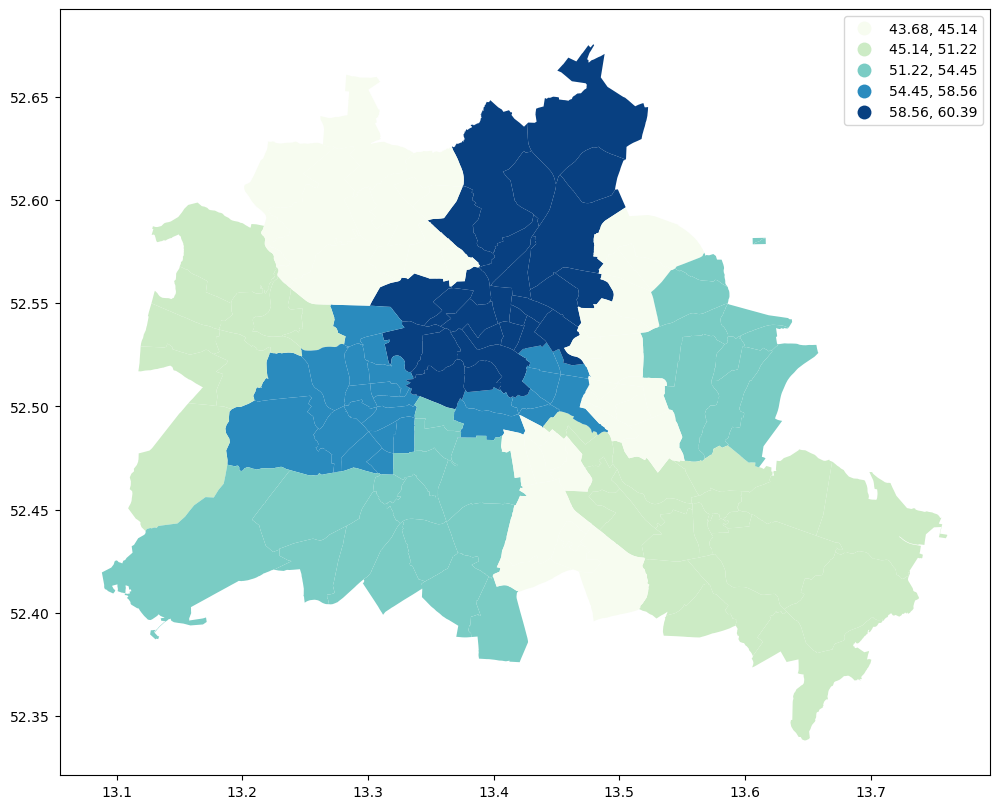

In [9]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
gdf.plot(column="median_pri", scheme="Quantiles", k=5, cmap="GnBu", legend=True, ax=ax)
# ax.set_xlim(150000, 160000)
# ax.set_ylim(208000, 215000)

In [10]:
df = gdf
wq = lps.weights.Queen.from_dataframe(df, use_index=False, silence_warnings=True)
wq.transform = "r"

In [11]:
y = df["median_pri"]
ylag = lps.weights.lag_spatial(wq, y)

In [12]:
y.median()

np.float32(53.704407)

In [13]:
yb = y > y.median()
sum(yb)

68

In [14]:
yb = y > y.median()
labels = ["0 Low", "1 High"]
yb = [labels[i] for i in 1 * yb]
df["yb"] = yb

<Axes: >

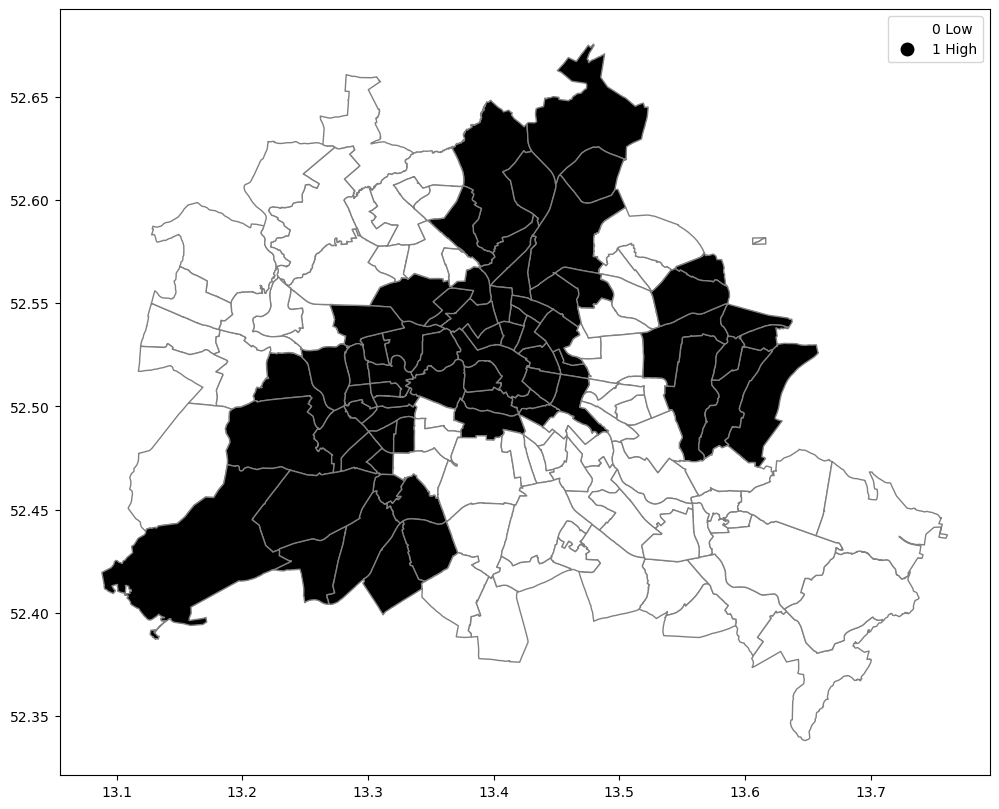

In [15]:
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={"aspect": "equal"})
df.plot(column="yb", cmap="binary", edgecolor="grey", legend=True, ax=ax)

In [16]:
yb = 1 * (y > y.median())  # convert back to binary
wq = lps.weights.Queen.from_dataframe(df, use_index=False, silence_warnings=True)
wq.transform = "b"
np.random.seed(12345)
jc = esda.join_counts.Join_Counts(yb, wq)

In [17]:
jc.bb

np.float64(164.0)

In [18]:
jc.ww

np.float64(149.0)

In [19]:
jc.bw

np.float64(73.0)

In [20]:
jc.bb + jc.ww + jc.bw

np.float64(386.0)

In [21]:
wq.s0 / 2

np.float64(386.0)

In [22]:
jc.bb

np.float64(164.0)

In [23]:
jc.mean_bb

np.float64(90.70170170170171)

Text(0.5, 0, 'BB Counts')

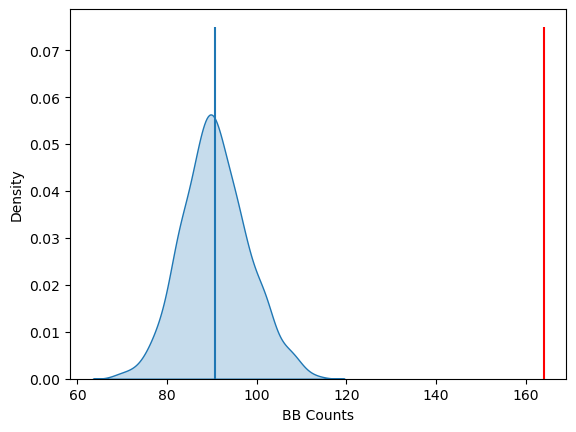

In [24]:
import seaborn as sbn

sbn.kdeplot(jc.sim_bb, fill=True)
plt.vlines(jc.bb, 0, 0.075, color="r")
plt.vlines(jc.mean_bb, 0, 0.075)
plt.xlabel("BB Counts")

In [25]:
jc.p_sim_bb

np.float64(0.001)